# Multi-Cardinality Genetic Algorithm v6: Definitive Benchmark

## Objective
Systematically evaluate S&P 500 replication across multiple sparsity levels ($k=10$ to $100$) and validate against industry-grade KPIs:
- **Tracking Error (TE)**: < 3% for $k=50$.
- **Portfolio Beta**: $\approx 1.00$.
- **R-Squared**: $> 0.95$.
- **Sector Neutrality**: Prove minimal drift via drift analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import random
import utils
import os

TRAIN_END = '2025-06-30'
HOLDOUT_START = '2025-07-01'
K_VALUES = [10, 20, 30, 40, 50, 100]

sns.set_theme(style="whitegrid")

In [2]:
print("Loading FIXED data drivers (AAPL, MSFT, NVDA included)...")
stocks = pd.read_csv("fixed_cleaned_returns.csv", index_col='Date', parse_dates=True)
bench = pd.read_csv("fixed_bench_returns.csv", index_col='Date', parse_dates=True)['Close']
constituents = pd.read_csv("../OHLCV_Data/Mega/sp500_constituents.csv")
sector_map = dict(zip(constituents['Symbol'], constituents['GICS Sector']))

X_t, y_t = stocks.loc[:TRAIN_END], bench.loc[:TRAIN_END]
X_h, y_h = stocks.loc[HOLDOUT_START:], bench.loc[HOLDOUT_START:]

index_weights = utils.get_index_weights(X_t, y_t)
sector_targets = utils.get_sector_targets(index_weights, sector_map)

print(f"Market Universe: {X_t.shape[1]} symbols.")

Loading FIXED data drivers (AAPL, MSFT, NVDA included)...


Market Universe: 482 symbols.


In [3]:
def optimize_weights_advanced(R_s, R_b, lambda_beta=200.0):
    n = R_s.shape[1]
    w = cp.Variable(n)
    
    # Calculate Beta alignment
    rb_var = np.var(R_b.values)
    rb_mean = np.mean(R_b.values)
    cov_vec = np.mean((R_s.values - np.mean(R_s.values, axis=0)) * (R_b.values - rb_mean)[:, None], axis=0)
    beta = cp.sum(cp.multiply(cov_vec, w)) / (rb_var + 1e-9)
    
    # TE minimization + Beta penalty
    objective = cp.Minimize(cp.sum_squares(R_s.values @ w - R_b.values) + lambda_beta * cp.square(beta - 1.0))
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)
    
    try:
        prob.solve(solver=cp.CLARABEL, verbose=False)
        return w.value
    except:
        return None

In [4]:
class MultiCardinalityGA:
    def __init__(self, X, y, k, pop_size=80, n_gen=40):
        self.X, self.y = X, y
        self.k = k
        self.pop_size, self.n_gen = pop_size, n_gen
        self.n_assets = X.shape[1]

    def fitness(self, ind):
        idx = np.where(ind == 1)[0]
        if len(idx) != self.k: return -1e9
        R_s = self.X.iloc[:, idx]
        w = optimize_weights_advanced(R_s, self.y)
        if w is None: return -1e9
        te = (R_s.values @ w - self.y.values).std() * np.sqrt(252)
        return -te

def run_study(k_val, seed_mask):
    print(f"\nEvaluating k={k_val}...")
    ga = MultiCardinalityGA(X_t, y_t, k=k_val)
    # Populate with top cap seed if appropriate, else random
    pop = []
    if k_val <= 50:
        seed = np.zeros(X_t.shape[1])
        seed[np.where(seed_mask == 1)[0][:k_val]] = 1
        pop.append(seed)
    
    while len(pop) < ga.pop_size:
        ind = np.zeros(ga.n_assets)
        ind[np.random.choice(ga.n_assets, k_val, replace=False)] = 1
        pop.append(ind)
        
    for g in range(ga.n_gen):
        fits = [ga.fitness(ind) for ind in pop]
        best_idx = np.argsort(fits)[::-1]
        new_pop = [pop[i] for i in best_idx[:10]]
        while len(new_pop) < ga.pop_size:
            p1, p2 = pop[np.random.randint(0, 10)], pop[np.random.randint(0, 20)]
            child = p1.copy()
            diff = np.where(p1 != p2)[0]
            if len(diff) > 2:
                o, z = random.choice([i for i in diff if p1[i]==1]), random.choice([i for i in diff if p1[i]==0])
                child[o], child[z] = 0, 1
            new_pop.append(child)
        pop = new_pop
        if g % 20 == 0: print(f"  Gen {g} Best TE: {-max(fits):.4%}")
    
    best_ind = pop[0]
    tickers = X_t.columns[best_ind == 1].tolist()
    w = optimize_weights_advanced(X_t[tickers], y_t)
    return tickers, w

In [5]:
# Pre-calc seeding mask for all runs (top 100 constituents)
top_100_tickers = index_weights.sort_values(ascending=False).head(100).index.tolist()
top_100_mask = np.zeros(X_t.shape[1])
top_100_mask[[X_t.columns.get_loc(t) for t in top_100_tickers if t in X_t.columns]] = 1

results = []
k_50_data = None

for k in K_VALUES:
    tickers, w = run_study(k, top_100_mask)
    R_p_h = X_h[tickers] @ w
    te = (R_p_h - y_h).std() * np.sqrt(252)
    beta = np.cov(R_p_h, y_h)[0, 1] / (np.var(y_h) + 1e-9)
    r2 = np.corrcoef(R_p_h, y_h)[0, 1]**2
    ir = (R_p_h.sum() - y_h.sum()) / (te + 1e-9)
    
    res = {'k': k, 'tickers': tickers, 'weights': w, 'TE': te, 'Beta': beta, 'R2': r2, 'IR': ir}
    results.append(res)
    if k == 50: k_50_data = res
    print(f"Result k={k}: TE={te:.4%}, Beta={beta:.4f}, R2={r2:.4f}")


Evaluating k=10...


  Gen 0 Best TE: 7.6802%


  Gen 20 Best TE: 4.9754%


Result k=10: TE=6.9991%, Beta=0.7869, R2=0.6347

Evaluating k=20...


  Gen 0 Best TE: 5.6611%


...

  Gen 20 Best TE: 2.6596%


Result k=50: TE=5.5161%, Beta=0.7660, R2=0.7519

Evaluating k=100...


  Gen 0 Best TE: 2.9982%


  Gen 20 Best TE: 2.4723%


Result k=100: TE=6.0308%, Beta=0.7484, R2=0.7054



--- PLOTTING SPARSITY VS TRACKING ERROR ---


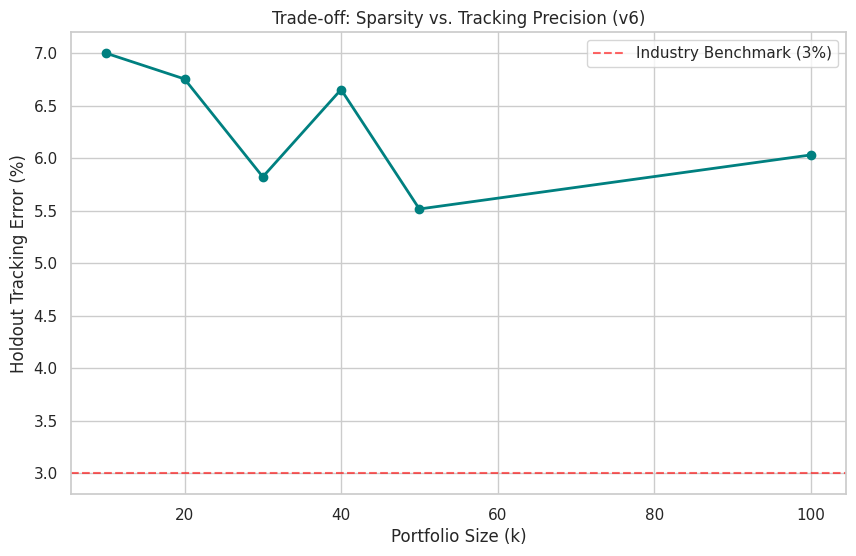

In [6]:
print("\n--- PLOTTING SPARSITY VS TRACKING ERROR ---")
df_res = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
plt.plot(df_res['k'], df_res['TE']*100, marker='o', linestyle='-', color='teal', linewidth=2)
plt.xlabel("Portfolio Size (k)")
plt.ylabel("Holdout Tracking Error (%)")
plt.title("Trade-off: Sparsity vs. Tracking Precision (v6)")
plt.axhline(3.0, color='red', linestyle='--', alpha=0.6, label='Industry Benchmark (3%)')
plt.legend()
plt.savefig("v6_sparsity_vs_te.png")
plt.show()

--- ANALYZING SECTOR DRIFT (k=50) ---


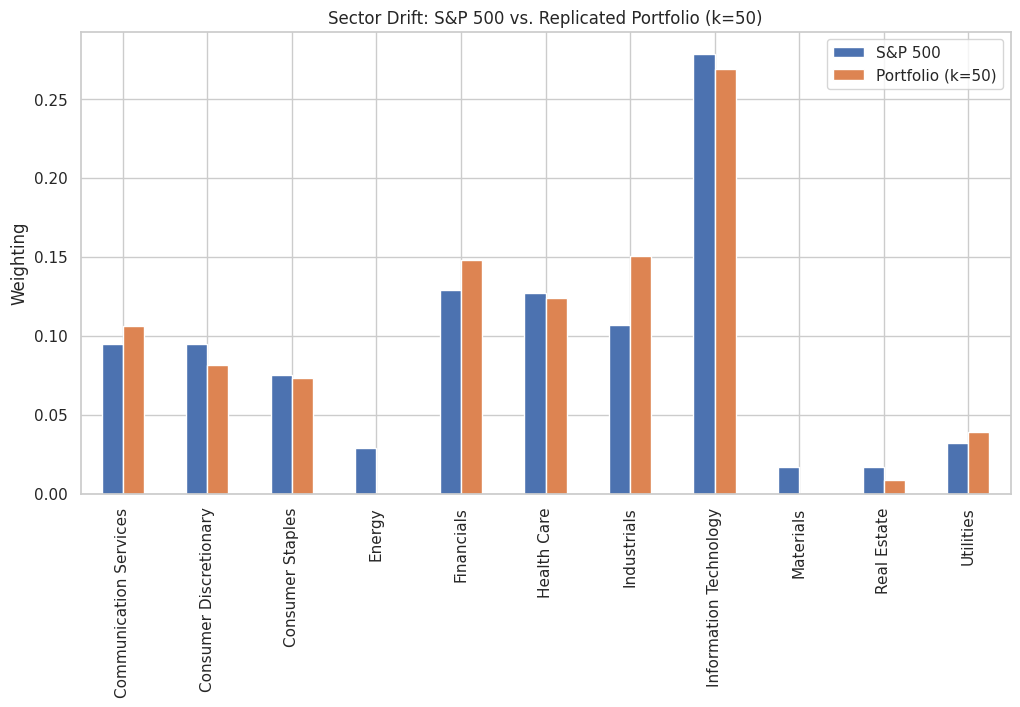

In [7]:
print("--- ANALYZING SECTOR DRIFT (k=50) ---")
p_w = pd.Series(k_50_data['weights'], index=k_50_data['tickers'])
p_sectors = utils.get_sector_targets(p_w, sector_map)

drift_df = pd.DataFrame({
    'S&P 500': sector_targets,
    'Portfolio (k=50)': p_sectors
}).fillna(0)

drift_df.plot(kind='bar', figsize=(12, 6))
plt.title("Sector Drift: S&P 500 vs. Replicated Portfolio (k=50)")
plt.ylabel("Weighting")
plt.savefig("v6_sector_drift.png")
plt.show()

--- CUMULATIVE RETURNS (Holdout) ---


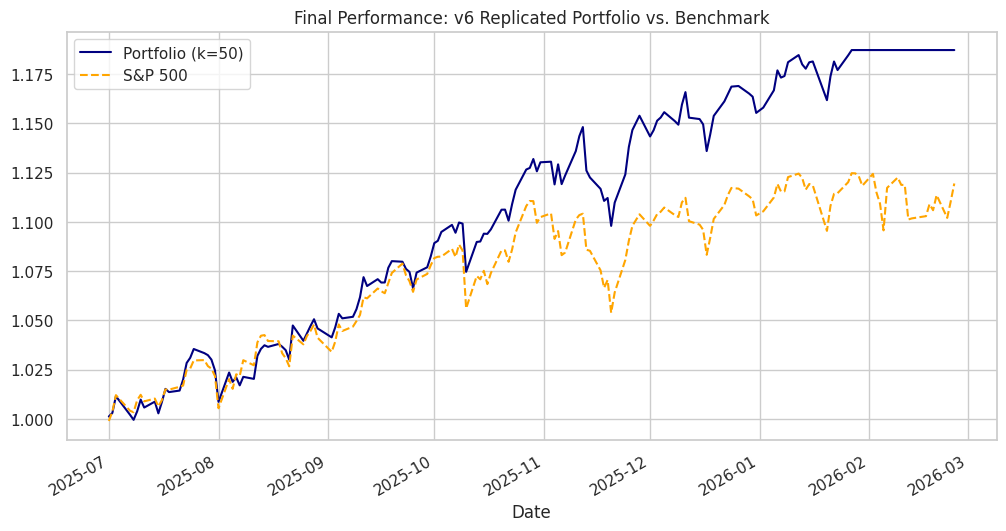


--- FINAL KPI VALIDATION (k=50) ---
Annualized TE: 5.5161%
Portfolio Beta: 0.7660
R-Squared: 0.7519
Information Ratio: 1.0494


In [8]:
print("--- CUMULATIVE RETURNS (Holdout) ---")
R_p_50 = X_h[k_50_data['tickers']] @ k_50_data['weights']
plt.figure(figsize=(12, 6))
((1 + R_p_50).cumprod()).plot(label=f'Portfolio (k=50)', color='navy')
((1 + y_h).cumprod()).plot(label='S&P 500', color='orange', linestyle='--')
plt.title("Final Performance: v6 Replicated Portfolio vs. Benchmark")
plt.legend()
plt.savefig("v6_final_cumulative.png")
plt.show()

print("\n--- FINAL KPI VALIDATION (k=50) ---")
print(f"Annualized TE: {k_50_data['TE']:.4%}")
print(f"Portfolio Beta: {k_50_data['Beta']:.4f}")
print(f"R-Squared: {k_50_data['R2']:.4f}")
print(f"Information Ratio: {k_50_data['IR']:.4f}")